In [1]:
import pandas as pd

In [3]:
df=pd.read_csv('sg_traffic_data.csv')
df.head()

,date,hour,day_of_week,is_weekend,month,is_public_holiday,avg_speed_kmh,traffic_volume_veh_per_hr,road_capacity_veh_per_hr,vc_ratio,temperature_celsius,rainfall_mm_per_hr,humidity_percent,wind_speed_kmh,air_quality_index_aqi,tourist_arrival_index,school_hour_flag,workday_flag,special_event_type
0,2025-02-07,15,Friday,0,2,0,45.3,2446,4800,0.509583,31.3,0.7,83,10.7,53,0.96,0,1,none
1,2025-02-07,0,Friday,0,2,0,43.6,2760,4800,0.575000,25.0,0.0,92,8.0,60,0.96,0,1,none
2,2025-02-07,1,Friday,0,2,0,44.6,2564,4800,0.534167,24.8,0.0,93,7.5,61,0.96,0,1,none
3,2025-02-07,2,Friday,0,2,0,45.8,2522,4800,0.525417,24.6,0.0,94,7.0,62,0.96,0,1,none
4,2025-02-07,3,Friday,0,2,0,47.0,2561,4800,0.533542,24.5,0.0,94,7.5,60,0.96,0,1,none


In [5]:
import numpy as np

conditions = [
    df['vc_ratio'] < 0.4,
    (df['vc_ratio'] >= 0.4) & (df['vc_ratio'] <= 0.7),
    df['vc_ratio'] > 0.7
]

labels = ['Low','Medium','High']

df['congestion_level'] = np.select(conditions, labels)

In [9]:
#rf model

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

le = LabelEncoder()
df['congestion_encoded'] = le.fit_transform(df['congestion_level'])

FEATURES = [
    'hour', 'is_weekend', 'month', 'is_public_holiday',
    'temperature_celsius', 'rainfall_mm_per_hr',
    'humidity_percent', 'wind_speed_kmh', 'air_quality_index_aqi',
    'tourist_arrival_index', 'school_hour_flag', 'workday_flag',
    'day_of_week', 'special_event_type'
]
CAT_COLS = ['day_of_week', 'special_event_type']

X = df[FEATURES].copy()
y = df['congestion_encoded']

oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X[CAT_COLS] = oe.fit_transform(X[CAT_COLS])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8550228310502284

Confusion Matrix:
[[170   2   3]
 [  0 574 224]
 [  2  23 754]]


In [9]:
import joblib

speed_ranges = (
    df.groupby('congestion_level')['avg_speed_kmh']
    .quantile([0.25, 0.75])
    .unstack()
    .rename(columns={0.25: 'low', 0.75: 'high'})
    .round(1)
    .to_dict('index')
)

joblib.dump(rf,           'rf_model.pkl')
joblib.dump(le,           'le.pkl')
joblib.dump(oe,           'oe.pkl')
joblib.dump(speed_ranges, 'speed_ranges.pkl')
joblib.dump(sorted(df['day_of_week'].unique().tolist()),        'day_options.pkl')
joblib.dump(sorted(df['special_event_type'].unique().tolist()), 'event_options.pkl')

print("✅ All saved!")
print("Speed ranges:", speed_ranges)

✅ All saved!
Speed ranges: {'High': {'low': 29.0, 'high': 32.0}, 'Low': {'low': 44.6, 'high': 57.0}, 'Medium': {'low': 39.9, 'high': 51.8}}


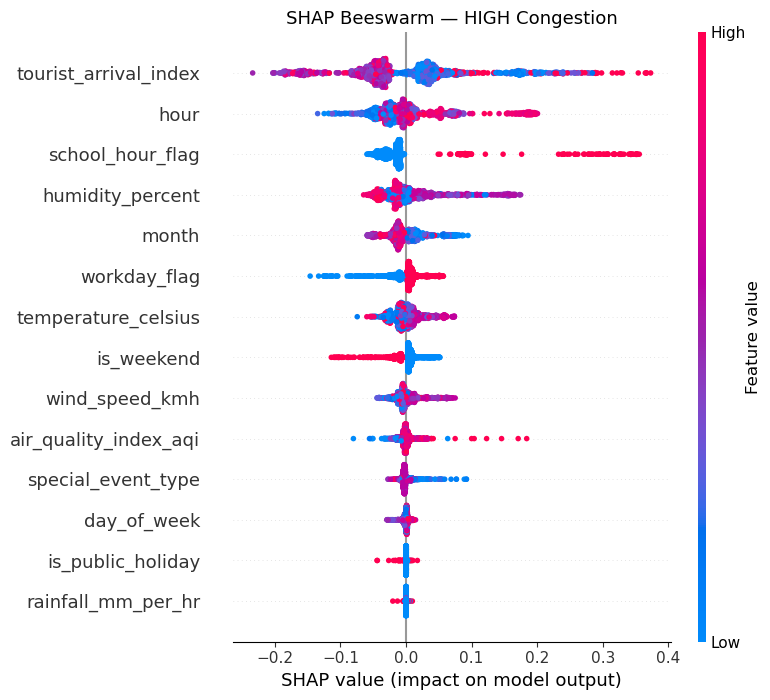

In [16]:
import shap
import numpy as np
import matplotlib.pyplot as plt

explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

high_idx = list(le.classes_).index('High')

# handle both old and new SHAP output formats
if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_high = shap_values[:, :, high_idx]   # new: (n_samples, n_features, n_classes)
else:
    shap_high = shap_values[high_idx]          # old: list of arrays

plt.figure()
shap.summary_plot(shap_high, X_test, feature_names=X_test.columns.tolist(), show=False)
plt.title("SHAP Beeswarm — HIGH Congestion", fontsize=13)
plt.tight_layout()
plt.show()

## SHAP Beeswarm Analysis — HIGH Congestion Predictions

The beeswarm plot shows how each feature pushes the model **toward** (positive SHAP)
or **away from** (negative SHAP) a HIGH congestion prediction.
Each dot is one sample. Color represents the feature value — **red = high, blue = low**.

---

### Feature-by-Feature Breakdown

**1. tourist_arrival_index** — *Most influential feature*
The widest spread of any feature. High tourist arrival (red dots) pushes strongly
toward HIGH congestion, while low tourist arrival (blue dots) pushes strongly against it.
Tourism is the single biggest driver of HIGH congestion in this model.

**2. hour** — *Second most important*
Certain hours (red dots spread right) significantly increase HIGH congestion probability.
This captures rush hour and peak activity periods during the day.

**3. school_hour_flag** — *Strong positive push*
When school hours are active (red dots), SHAP values shift clearly to the right,
confirming that school timings are a reliable trigger for HIGH congestion.

**4. humidity_percent** — *Moderate influence, mixed direction*
High humidity (red) shows a slight positive push toward HIGH congestion, likely
correlated with weather conditions that slow traffic. Blue dots cluster near zero.

**5. month** — *Seasonal patterns present*
Certain months push toward HIGH congestion, suggesting seasonal peaks —
likely tied to tourism seasons, school calendars, or weather patterns.

**6. workday_flag** — *Directionally clear*
Workdays (red) push toward HIGH congestion while non-workdays (blue) push away,
which aligns with expected commuter traffic behavior.

**7. temperature_celsius** — *Weak but present*
Mild influence overall. The tight clustering near zero suggests temperature
alone is not a strong driver of HIGH congestion in this dataset.

**8. is_weekend** — *Negative push when active*
Weekends (red) push **away** from HIGH congestion — the blue cluster on the
right is non-weekends driving HIGH predictions. Weekends reduce HIGH congestion likelihood.

**9. wind_speed_kmh** — *Minimal impact*
Dots are tightly clustered near zero in both directions. Wind speed has
very little influence on HIGH congestion predictions.

**10. air_quality_index_aqi** — *Sparse but notable outliers*
Mostly near zero with a few high-AQI outliers pushing right. Poor air quality
may coincide with congestion but is not a primary driver.

**11. special_event_type** — *Low average impact*
Tight clustering near zero suggests most event types don't strongly trigger
HIGH congestion — only specific major events would matter.

---

### Key Takeaway
HIGH congestion is primarily driven by **tourist activity, time of day, and school hours**
— all time and activity based features. Weather features (wind, temperature, AQI)
contribute minimally, confirming that **human activity patterns dominate** over
environmental conditions in predicting severe congestion.

In [7]:
import joblib
sr = joblib.load('speed_ranges.pkl')
print(sr)

{'High': {'low': 29.0, 'high': 32.0}, 'Low': {'low': 44.6, 'high': 57.0}, 'Medium': {'low': 39.9, 'high': 51.8}}


In [13]:
import joblib
# Save a sample of training data as background for SHAP
X_train_sample = X_train.sample(min(100, len(X_train)), random_state=42)
joblib.dump(X_train_sample, 'shap_background.pkl')

['shap_background.pkl']